In [46]:
import numpy as np #hacer cálculos matemáticos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [47]:
df = pd.read_csv("/content/sample_data/Data_PI_regresion.csv")
df.head() #vamos los 5 primeros datos del data frame

,Temperatura,Horas_Operacion,Carga,Humedad,Consumo_Energia
0,29.8,7.4,76.4,87.0,28.97
1,22.9,4.3,88.8,74.9,21.85
2,21.9,10.4,87.7,65.7,37.43
3,27.4,7.8,55.7,79.0,26.32
4,30.2,6.9,42.3,62.9,26.08


In [48]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Temperatura      5000 non-null   float64
 1   Horas_Operacion  5000 non-null   float64
 2   Carga            5000 non-null   float64
 3   Humedad          5000 non-null   float64
 4   Consumo_Energia  5000 non-null   float64
dtypes: float64(5)
memory usage: 195.4 KB


In [49]:
#describe permite dar un resumen estadistico, acondiciono redondeo
df.describe().round(2)

,Temperatura,Horas_Operacion,Carga,Humedad,Consumo_Energia
count,5000.00,5000.00,5000.00,5000.00,5000.00
mean,26.46,6.99,65.04,65.12,26.05
std,4.94,2.86,20.28,14.33,5.62
min,18.00,2.00,30.00,40.00,9.12
25%,22.10,4.40,47.30,52.70,21.79
50%,26.50,7.00,65.70,65.00,26.08
75%,30.70,9.40,82.52,77.50,30.26
max,35.00,12.00,100.00,90.00,42.63


In [50]:
#para ver las caracteristicas
df.columns

Index(['Temperatura', 'Horas_Operacion', 'Carga', 'Humedad',
       'Consumo_Energia'],
      dtype='object')

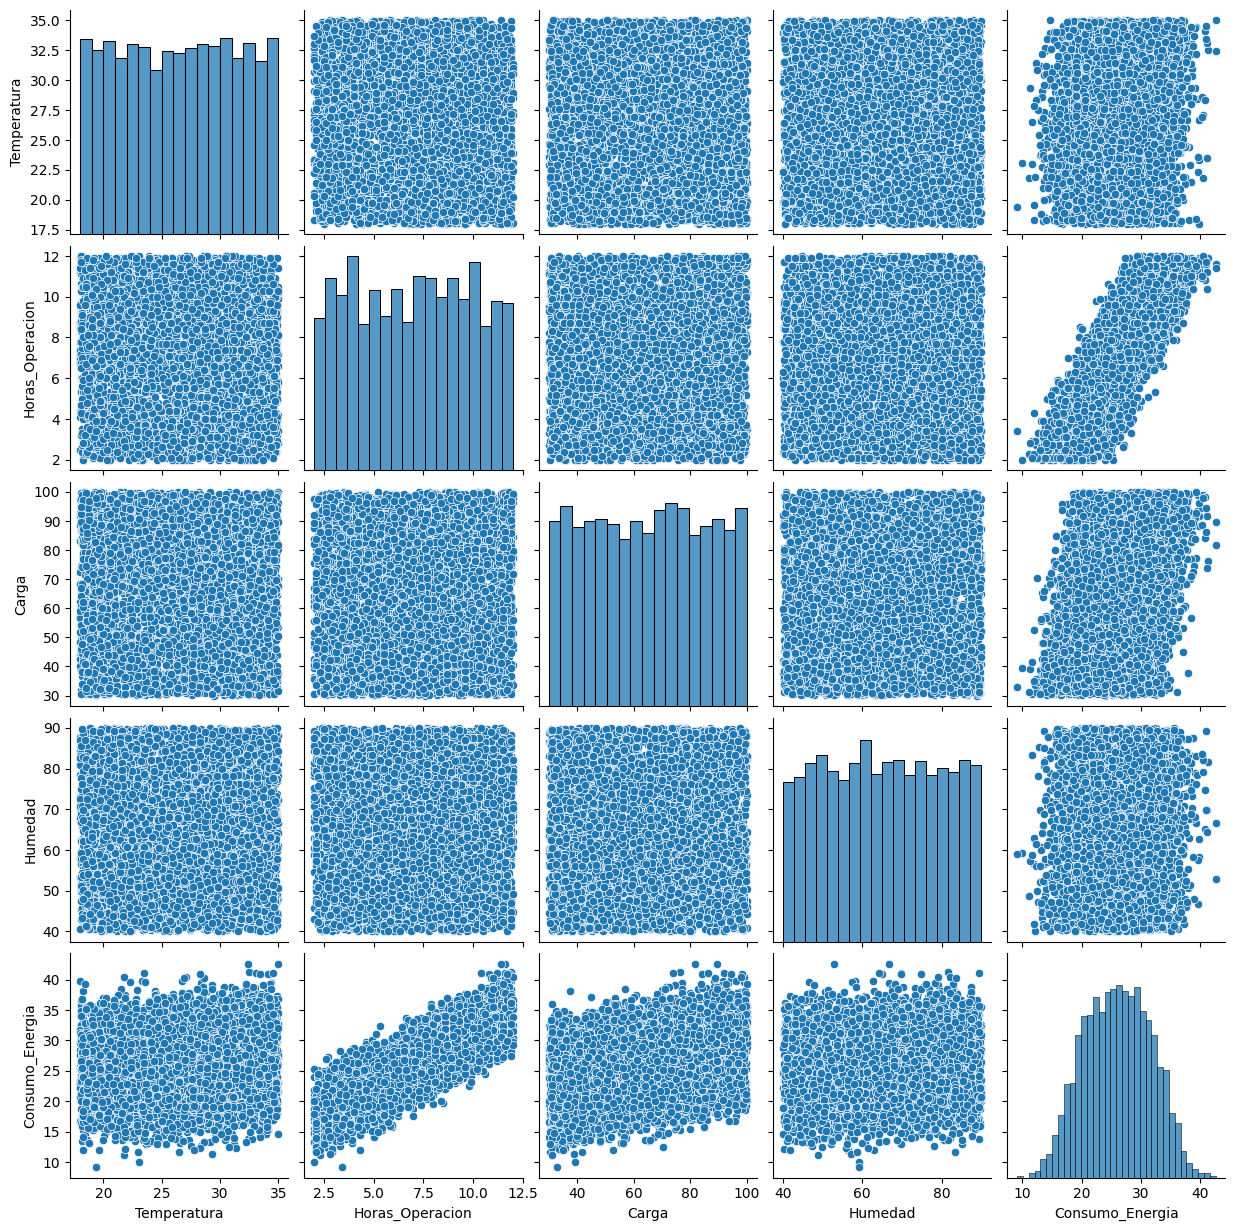

In [51]:
#Visualización básica
sns.pairplot(df)

<Axes: ylabel='Frequency'>

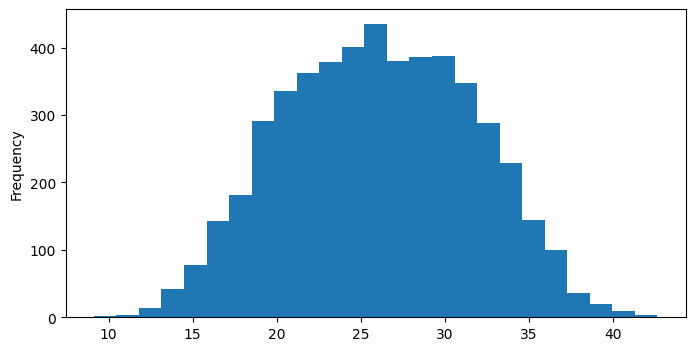

In [52]:
#ahora de la columna de consumo de energía
df["Consumo_Energia"].plot.hist(bins=25, figsize=(8,4))
#histogerama en 25, como agrupar los datos
#figsize tamaño de la figura

<Axes: ylabel='Density'>

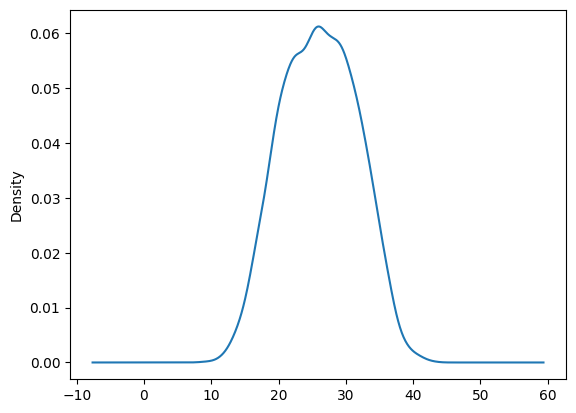

In [53]:
df["Consumo_Energia"].plot.density()

In [54]:
numeric_df = df.select_dtypes(include=[np.number])
#selecciona solo las columnas con valores numericos
numeric_df.corr().round(4)
#calculo de la correlacion relacion entre dos variables

,Temperatura,Horas_Operacion,Carga,Humedad,Consumo_Energia
Temperatura,1.0000,-0.0260,0.0102,0.0166,0.0978
Horas_Operacion,-0.0260,1.0000,-0.0099,0.0060,0.8434
Carga,0.0102,-0.0099,1.0000,0.0060,0.3366
Humedad,0.0166,0.0060,0.0060,1.0000,0.0627
Consumo_Energia,0.0978,0.8434,0.3366,0.0627,1.0000


<Axes: >

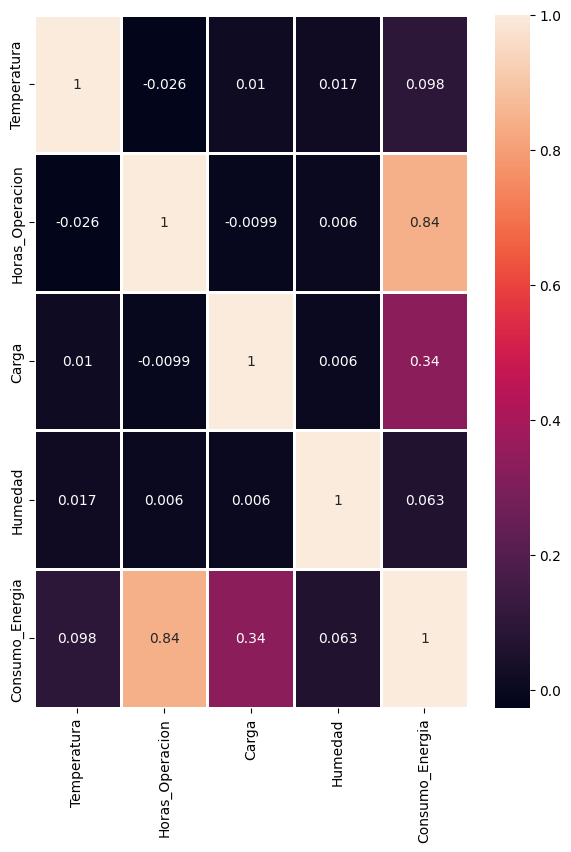

In [55]:
plt.figure(figsize=(7,9))
sns.heatmap(numeric_df.corr(), annot = True, linewidths=2)
#mapa de calor de correlaciones

Conjunto de carácterísticas y variables

In [56]:
l_column= list(df.columns) #haciendo una lista de las columnas
len_feature = len(l_column) #longitud de la lista de vectores de columna
l_column

['Temperatura', 'Horas_Operacion', 'Carga', 'Humedad', 'Consumo_Energia']

Regresión lineal

In [57]:
X = df[l_column[0:len_feature-1]]
Y = df[l_column[len_feature-1]]
X.head() #para mostrar las primeras 5 filas siempre



,Temperatura,Horas_Operacion,Carga,Humedad
0,29.8,7.4,76.4,87.0
1,22.9,4.3,88.8,74.9
2,21.9,10.4,87.7,65.7
3,27.4,7.8,55.7,79.0
4,30.2,6.9,42.3,62.9


In [58]:
Y.head()

,Consumo_Energia
0,28.97
1,21.85
2,37.43
3,26.32
4,26.08


dividir entre entrenamiento y prueba
#

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
X_train, X_test, Y_train, Y_test = train_test_split(
X, Y, test_size=0.3, random_state=123
)
#70% entrenamiento
#30%

In [61]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [62]:
lm = LinearRegression()

In [63]:
lm.fit(X_train, Y_train)

LinearRegression()

Ajuste y entrenamiento del modelo

In [64]:
#verificamos la intercepcion
print("el termino de interseccion del modelo lineal: ", lm.intercept_)

el termino de interseccion del modelo lineal:  2.741067446117448


In [65]:
#Verificamos el modelo lineal
print("Los coeficientes del modelo lineal:", lm.coef_)

Los coeficientes del modelo lineal: [0.13713677 1.66877804 0.09634816 0.02679108]


In [66]:
cdf = pd.DataFrame(data=lm.coef_, index= X_train.columns, columns=["Coeficiente"])
cdf

,Coeficiente
Temperatura,0.137137
Horas_Operacion,1.668778
Carga,0.096348
Humedad,0.026791


In [67]:
n=X_train.shape[0] # cantidad de datos de entrenamiento
k=X_train.shape[1] # cantidad de variables: 4
dfN = n-k # grados de libertad
train_pred=lm.predict(X_train) # obtener predicciones

# calculamos el error: R^2
train_error = np.square(train_pred - Y_train) # comparamos (prediccion - valor real) **2
sum_error =np.sum(train_error) # suma de errores
# ¿qué tanto se equivocó el modelo?

se=[0,0,0,0]
for i in range(k):
  r = (sum_error/dfN)
  # ¿cuánto varia el valor respecto a su promedio?
  #selecciona variable: 'Temperatura' calcula la Temperatura promedio
  r = r/np.sum(np.square(X_train[list(X_train.columns)[i]]-X_train[list(X_train.columns)[i]].mean()))
  se[i]=np.sqrt(r) # cálculo del error estándar
cdf['Standard Error']=se
cdf['t-statistic']=cdf['Coeficiente']/cdf['Standard Error']
cdf
# ¿El coeficiente es grande en comparación con la incertidumbre que tiene?
# ¿está alejado de cero respecto a su error estándar?

,Coeficiente,Standard Error,t-statistic
Temperatura,0.137137,0.007557,18.147233
Horas_Operacion,1.668778,0.013138,127.020720
Carga,0.096348,0.001859,51.826973
Humedad,0.026791,0.002611,10.260097


RANDOM FORREST



In [68]:
from ast import increment_lineno
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import numpy as np

#importar el método make_regression para generar muestras de datos artificiales
from sklearn.datasets import make_regression

In [69]:
# Importar el método make_regression para generar muestras de datos artificiales
from sklearn.datasets import make_regression

In [70]:
n_samples = 100 # Número de muestras
n_features = 6 # Número de características
n_informative = 3 # Número de características informativas,
          # es decir, características reales que influyen en la salida

In [71]:
X, Y, coef = make_regression(
  n_samples=n_samples,
  n_features=n_features,
  n_informative=n_informative,
  random_state=20, # semilla aleatoria (reproducibilidad)
  shuffle=False,  # que no se mezclen las características
  noise=20,    # ruido aleatorio
  coef=True
)
print(coef) # devuelve los coeficientes

[78.58638696 97.72361019 52.30606265  0.          0.          0.        ]


CREAR DATA FRAME

In [72]:
df = pd.DataFrame(
    data=X,
    columns=['X' + str(i) for i in range(1, n_features + 1)]
)
df2 = pd.DataFrame(
    data=Y,
    columns=['Y']
)
df3 = pd.concat([df, df2], axis=1)
df3.head(10)

,X1,X2,X3,X4,X5,X6,Y
0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,109.512132
1,0.939469,-0.978481,0.503097,0.406414,0.323461,-0.493411,52.542242
2,-0.792017,-0.842368,-1.279503,0.245715,-0.044195,1.567633,-247.679018
3,1.051109,0.406368,-0.168646,-3.189703,1.120132,1.332778,98.678111
4,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-55.286890
5,-0.885493,-1.104579,0.932866,2.059838,-0.934938,-1.612990,-94.821349
6,0.527070,-1.551101,0.329613,-1.136527,-0.338491,0.320971,-75.940071
7,-0.602308,1.544728,0.647034,0.593217,0.438024,1.357789,139.247064
8,1.204511,1.351796,0.493437,-2.704365,-0.555186,0.001509,246.470338
9,0.857094,1.481144,-0.219661,1.503398,-1.482385,-0.856164,204.709196


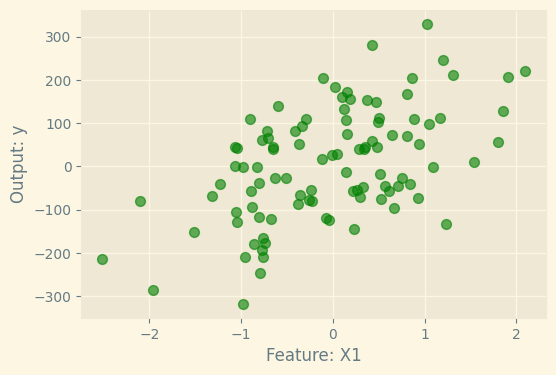

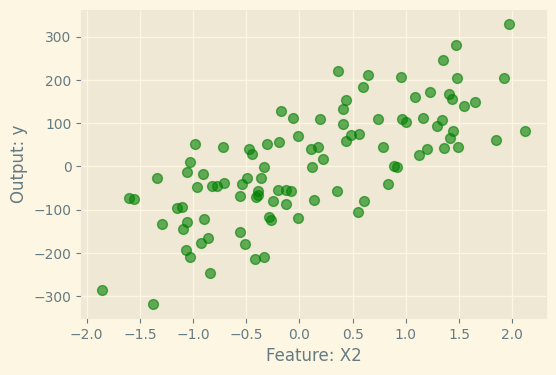

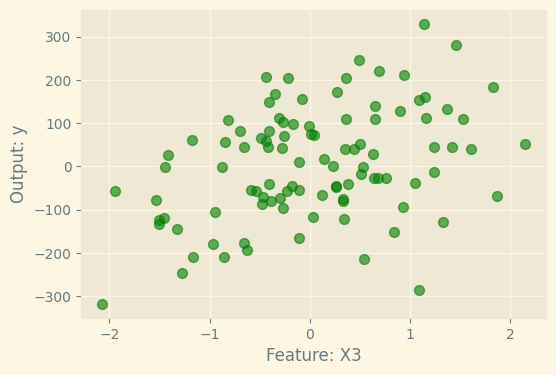

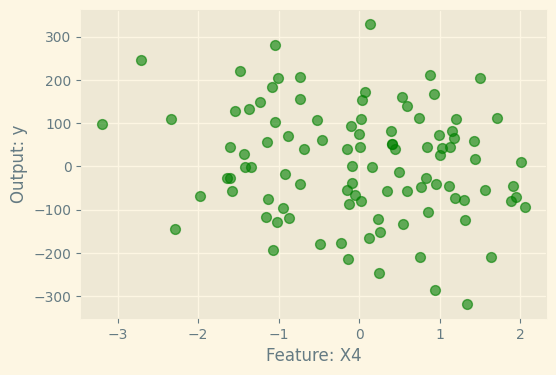

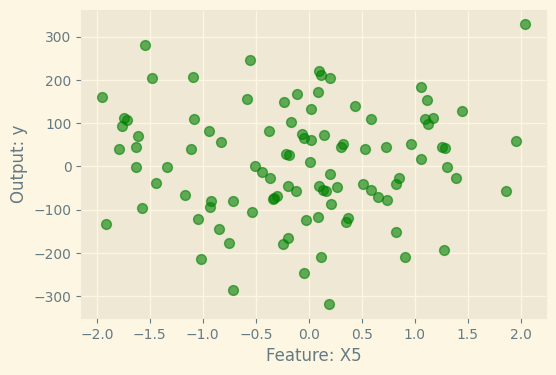

In [73]:
with plt.style.context('Solarize_Light2'):
  for i, col in enumerate(df.columns[:-1]):
    plt.figure(figsize=(6, 4))
    plt.grid(True)
    plt.xlabel('Feature: ' + col, fontsize=12)
    plt.ylabel('Output: y', fontsize=12)
    plt.scatter(df3[col], df3['Y'], c='green', s=50, alpha=0.6)

ÁRBOL DE DESICIONES

In [74]:
from sklearn import tree
from sklearn.model_selection import train_test_split

In [75]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=123
)
#para hacer que se mandenta reproducible, por mas q los valores sean aleatorios,
#ya esta mapeada, al volver a ejecutar ya te da un valor vistgo antes

In [76]:
#creación del modelo
tree_model = tree.DecisionTreeRegressor(max_depth=5, random_state=10)
# niveles de decisión
tree_model.fit(X_train, Y_train)


DecisionTreeRegressor(max_depth=5, random_state=10)

Mean square error (MSE): 7931.574768958281


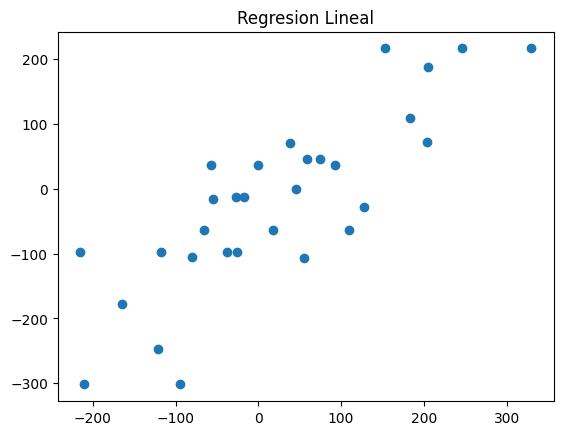

In [77]:
from sklearn import metrics
# Hacemos predicciones
test_pred = tree_model.predict(X_test)
plt.scatter(x=Y_test, y=test_pred)
plt.title("Regresion Lineal")  # real vs predicho
print("Mean square error (MSE):", metrics.mean_squared_error(Y_test, test_pred))
# Error cuadrático medioz

Importancia relativa de las características:  [0.26900246 0.53730467 0.11075698 0.03758107 0.01219288 0.03316193]


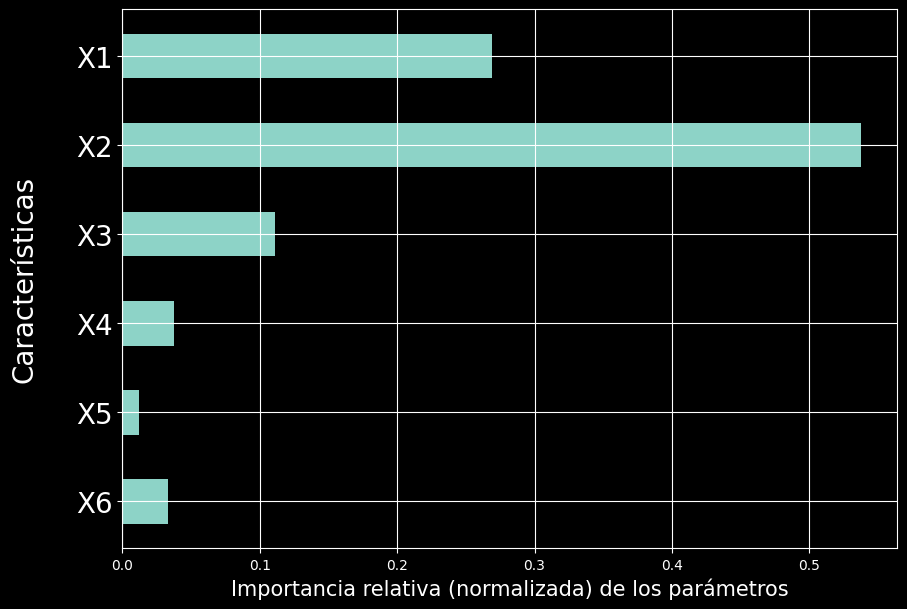

In [78]:
print("Importancia relativa de las características: ", tree_model.feature_importances_)
with plt.style.context('dark_background'):
    plt.figure(figsize=(10, 7))
    plt.grid(True)
    plt.yticks(range(n_features + 1, 1, -1), df3.columns[:-1], fontsize=20)
    plt.xlabel("Importancia relativa (normalizada) de los parámetros", fontsize=15)
    plt.ylabel("Características\n", fontsize=20)
    plt.barh(range(n_features + 1, 1, -1), width=tree_model.feature_importances_, height=0.5)

Minimos Cuadrados

In [79]:
import statsmodels.api as sm

In [80]:
Xs = sm.add_constant(X)
stat_model = sm.OLS(Y, Xs)
stat_result = stat_model.fit()
print(stat_result.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     628.6
Date:                Wed, 16 Sep 2026   Prob (F-statistic):           5.97e-73
Time:                        08:00:04   Log-Likelihood:                -440.25
No. Observations:                 100   AIC:                             894.5
Df Residuals:                      93   BIC:                             912.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.8565      2.087     -1.848      0.0